# Abhishek Kothari
# Assignment 3

### Question 1

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [5]:
from sklearn.datasets import fetch_openml, fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X_mnist, y_mnist = mnist.data, mnist.target.astype(int)

# Load Spambase data (no header in the file)
spambase_data = pd.read_csv("spambase/spambase.data", header=None)

# Define feature names manually as per the .names file
feature_names = [
    *[f"word_freq_{i}" for i in range(48)],  # 48 word frequency features
    *[f"char_freq_{i}" for i in range(6)],   # 6 character frequency features
    "capital_run_length_average", "capital_run_length_longest", "capital_run_length_total",  # 3 capital letter run features
    "label"  # Target variable
]

# Assign correct column names
spambase_data.columns = feature_names

# Split into features and labels
X_spam = spambase_data.drop(columns=["label"])
y_spam = spambase_data["label"]

# Load 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
vectorizer = TfidfVectorizer(max_features=5000)  # Convert text to TF-IDF features
X_20ng = vectorizer.fit_transform(newsgroups.data)
y_20ng = newsgroups.target

In [7]:
# Dataset dictionary for looping
datasets = {
    "MNIST": (X_mnist, y_mnist),
    "Spambase": (X_spam, y_spam),
    "20NG": (X_20ng, y_20ng)
}

In [8]:
# Standardize numerical datasets (except text)
scaler = StandardScaler()
X_mnist = scaler.fit_transform(X_mnist)
X_spam = scaler.fit_transform(X_spam)


In [9]:
# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10)  # Initial depth 10
}


In [10]:
# Results storage
results = {}

# Train & Evaluate Models
for dataset_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    for model_name, model in models.items():
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        # Feature importance extraction
        if model_name == "Logistic Regression":
            feature_importance = np.abs(model.coef_).sum(axis=0)  # L2 weight magnitudes
            top_features = np.argsort(feature_importance)[-30:]  # Get top 30
        elif model_name == "Decision Tree":
            top_features = model.tree_.feature[:30]  # First 30 splits

        # Store results
        results[(dataset_name, model_name)] = {
            "Accuracy": acc,
            "Top Features": top_features
        }

In [15]:
# Get feature names for each dataset
mnist_feature_names = [f"pixel_{i}" for i in range(X_mnist.shape[1])]
spam_feature_names = feature_names[:-1]  # Exclude the label column
ng_feature_names = vectorizer.get_feature_names_out()

# Map dataset names to feature names
feature_name_map = {
    "MNIST": mnist_feature_names,
    "Spambase": spam_feature_names,
    "20NG": ng_feature_names
}

# Convert indices to feature names
for (dataset_name, model_name), result in results.items():
    top_indices = result["Top Features"]
    feature_names = feature_name_map[dataset_name]
    
    # Some decision tree outputs contain -2 (indicating unused splits), so we filter them out
    result["Top Features"] = [feature_names[i] for i in top_indices if i >= 0]



In [16]:
# Print results
for (dataset, model), res in results.items():
    print(f"Dataset: {dataset}, Model: {model}")
    print(f"Accuracy: {res['Accuracy']:.4f}")
    print(f"Top Features: {res['Top Features']}\n")

Dataset: MNIST, Model: Logistic Regression
Accuracy: 0.9159
Top Features: ['pixel_504', 'pixel_590', 'pixel_676', 'pixel_224', 'pixel_41', 'pixel_195', 'pixel_304', 'pixel_223', 'pixel_743', 'pixel_667', 'pixel_705', 'pixel_110', 'pixel_474', 'pixel_90', 'pixel_750', 'pixel_614', 'pixel_67', 'pixel_366', 'pixel_723', 'pixel_225', 'pixel_309', 'pixel_362', 'pixel_338', 'pixel_89', 'pixel_282', 'pixel_697', 'pixel_363', 'pixel_563', 'pixel_670', 'pixel_503']

Dataset: MNIST, Model: Decision Tree
Accuracy: 0.8574
Top Features: ['pixel_350', 'pixel_435', 'pixel_597', 'pixel_486', 'pixel_404', 'pixel_538', 'pixel_153', 'pixel_460', 'pixel_542', 'pixel_157', 'pixel_209', 'pixel_409', 'pixel_324', 'pixel_460', 'pixel_350', 'pixel_372', 'pixel_211', 'pixel_293']

Dataset: Spambase, Model: Logistic Regression
Accuracy: 0.9229
Top Features: ['word_freq_5', 'word_freq_4', 'word_freq_8', 'word_freq_46', 'word_freq_44', 'word_freq_29', 'word_freq_3', 'word_freq_42', 'word_freq_25', 'word_freq_38', 

### Question 2

In [17]:
### A)

In [19]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Apply PCA to MNIST (D=5 and D=20)
def apply_pca_and_evaluate(X, y, D, dataset_name):
    pca = PCA(n_components=D)
    X_pca = pca.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Using Logistic Regression as an example model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Dataset: {dataset_name}, PCA Dimensions: {D}, Accuracy: {accuracy:.4f}")

    return accuracy

In [ ]:
# PCA on MNIST
acc_mnist_5 = apply_pca_and_evaluate(X_mnist, y_mnist, D=5, dataset_name="MNIST")
acc_mnist_20 = apply_pca_and_evaluate(X_mnist, y_mnist, D=20, dataset_name="MNIST")

In [ ]:
### B)

In [20]:
# Find smallest D for Spambase to match original accuracy
original_spam_acc = results[("Spambase", "Logistic Regression")]["Accuracy"]
best_D = None

for D in range(1, X_spam.shape[1]):  # Iterating over possible D values
    acc_spam = apply_pca_and_evaluate(X_spam, y_spam, D=D, dataset_name="Spambase")
    if acc_spam >= original_spam_acc * 0.98:  # Allow slight tolerance (98% of original acc)
        best_D = D
        print(f"Optimal PCA Dimension for Spambase: {D}")
        break  # Stop once comparable accuracy is achieved

Dataset: MNIST, PCA Dimensions: 5, Accuracy: 0.6791
Dataset: MNIST, PCA Dimensions: 20, Accuracy: 0.8689
Dataset: Spambase, PCA Dimensions: 1, Accuracy: 0.8404
Dataset: Spambase, PCA Dimensions: 2, Accuracy: 0.8675
Dataset: Spambase, PCA Dimensions: 3, Accuracy: 0.8719
Dataset: Spambase, PCA Dimensions: 4, Accuracy: 0.8784
Dataset: Spambase, PCA Dimensions: 5, Accuracy: 0.8762
Dataset: Spambase, PCA Dimensions: 6, Accuracy: 0.8719
Dataset: Spambase, PCA Dimensions: 7, Accuracy: 0.8838
Dataset: Spambase, PCA Dimensions: 8, Accuracy: 0.8838
Dataset: Spambase, PCA Dimensions: 9, Accuracy: 0.8947
Dataset: Spambase, PCA Dimensions: 10, Accuracy: 0.9012
Dataset: Spambase, PCA Dimensions: 11, Accuracy: 0.9045
Optimal PCA Dimension for Spambase: 11


### Question 3

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def my_pca(X, D):
    """Custom PCA implementation using NumPy"""
    # Step 1: Mean Centering
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    # Step 2: Compute Covariance Matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)

    # Step 3: Compute Eigenvalues and Eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)  # Efficient for symmetric matrices

    # Step 4: Sort eigenvectors by decreasing eigenvalues
    sorted_indices = np.argsort(eigenvalues)[::-1]  # Descending order
    top_eigenvectors = eigenvectors[:, sorted_indices[:D]]  # Select top D components

    # Step 5: Project Data onto Principal Components
    X_pca = np.dot(X_centered, top_eigenvectors)

    return X_pca

def apply_my_pca_and_evaluate(X, y, D, dataset_name):
    """Applies custom PCA and evaluates classification performance"""
    X_pca = my_pca(X, D)  # Perform PCA

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    # Train and evaluate model (Logistic Regression as an example)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Dataset: {dataset_name}, PCA Dimensions: {D}, Accuracy: {accuracy:.4f}")

    return accuracy

# Apply PCA on MNIST with D=5 and D=20
acc_mnist_5_custom = apply_my_pca_and_evaluate(X_mnist, y_mnist, D=5, dataset_name="MNIST (Custom PCA)")
acc_mnist_20_custom = apply_my_pca_and_evaluate(X_mnist, y_mnist, D=20, dataset_name="MNIST (Custom PCA)")

Dataset: MNIST (Custom PCA), PCA Dimensions: 5, Accuracy: 0.6791
Dataset: MNIST (Custom PCA), PCA Dimensions: 20, Accuracy: 0.8689


### Question 4

In [2]:
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [18]:
### A)

In [9]:
mnist = fetch_openml('mnist_784', version=1)
X_mnist, y_mnist = mnist.data[:5000], mnist.target[:5000].astype(int)

# (A) KMeans Clustering
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_mnist)


In [11]:
# (B) Custom PCA with 3 components
def my_pca(X, D):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    covariance_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    top_eigenvectors = eigenvectors[:, sorted_indices[:D]]
    X_pca = np.dot(X_centered, top_eigenvectors)
    return X_pca, eigenvalues, eigenvectors

Text(0.5, 0, 'PC3')

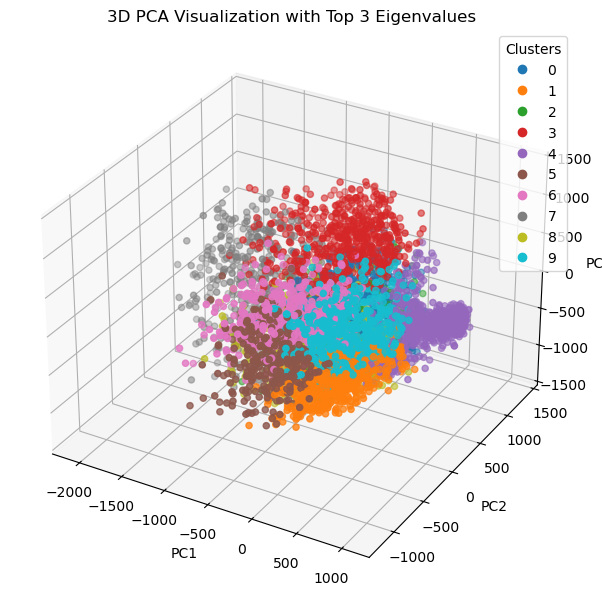

In [13]:
X_pca, eigenvalues, eigenvectors = my_pca(X_mnist, 3)

# (C) 3D Visualization using top 3 eigenvalues
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(121, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels, cmap='tab10', marker='o')
plt.legend(*scatter.legend_elements(), title='Clusters')
ax.set_title('3D PCA Visualization with Top 3 Eigenvalues')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')


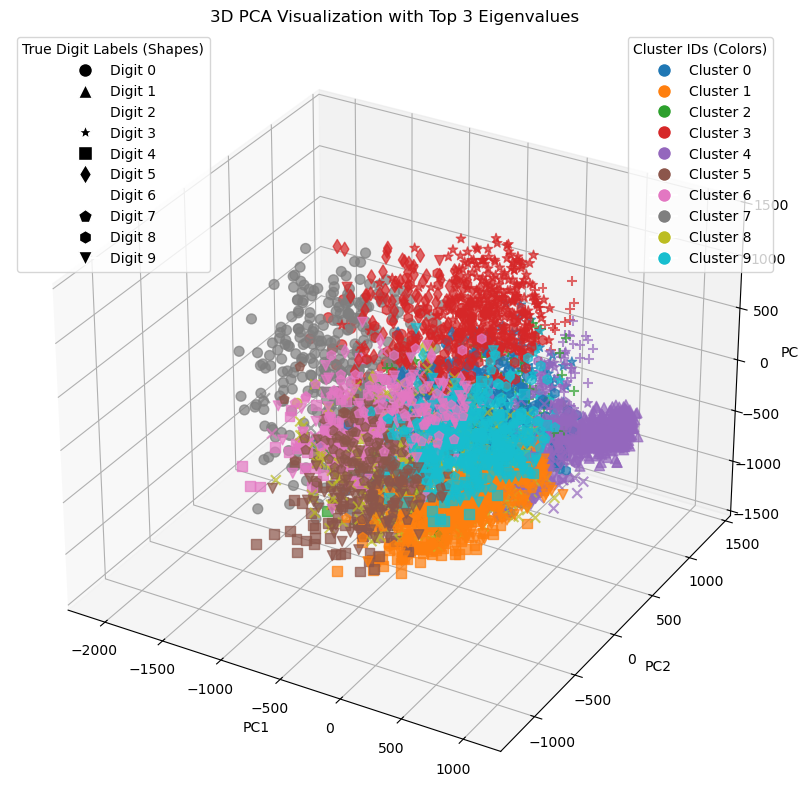

In [15]:
# Define unique markers for each true digit label (0-9)
markers = ['o', '^', '+', '*', 's', 'd', 'x', 'p', 'h', 'v']
colors = plt.cm.tab10(np.arange(10))  # Get 10 distinct colors for clusters

# Create a 3D plot
fig = plt.figure(figsize=(18, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each digit with corresponding shape and color based on cluster
for digit in range(10):
    mask = (y_mnist == digit)  # True digit mask
    for cluster_id in np.unique(kmeans_labels):
        cluster_mask = (kmeans_labels == cluster_id) & mask
        ax.scatter(
            X_pca[cluster_mask, 0],
            X_pca[cluster_mask, 1],
            X_pca[cluster_mask, 2],
            color=colors[cluster_id],   # Color for cluster ID
            marker=markers[digit],      # Shape for true digit label
            s=50, alpha=0.7
        )

ax.set_title('3D PCA Visualization with Top 3 Eigenvalues')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Create legends for true digit labels (shapes) and cluster colors
shape_handles = [plt.Line2D([0], [0], marker=markers[i], color='w', markerfacecolor='black', markersize=10, label=f'Digit {i}') for i in range(10)]
color_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], markersize=10, label=f'Cluster {i}') for i in range(10)]

# Add legends
legend1 = ax.legend(handles=shape_handles, title='True Digit Labels (Shapes)', loc='upper left')
ax.add_artist(legend1)
ax.legend(handles=color_handles, title='Cluster IDs (Colors)', loc='upper right')

plt.show()

/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


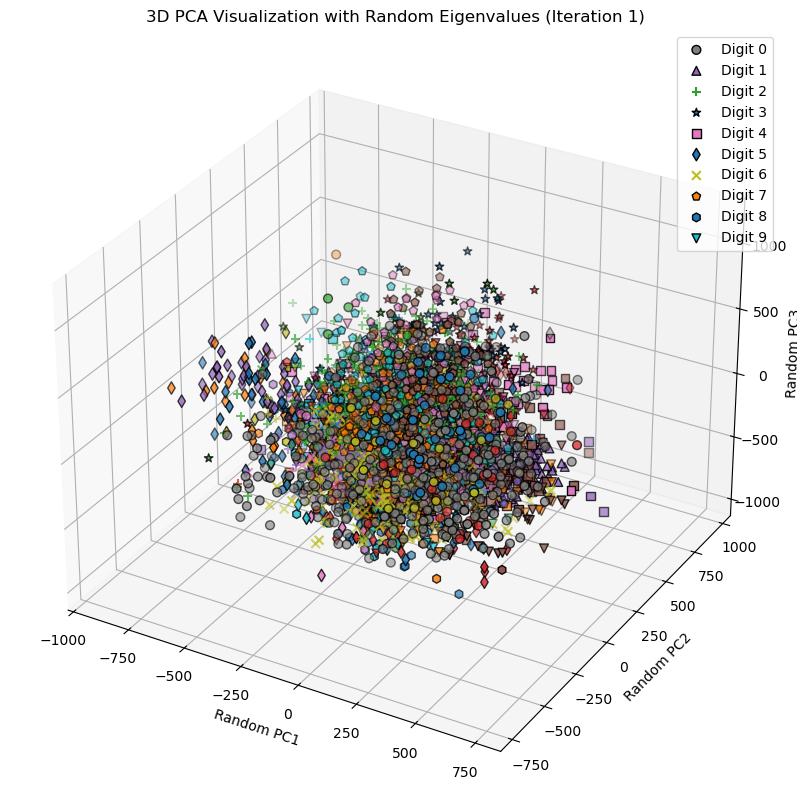

/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


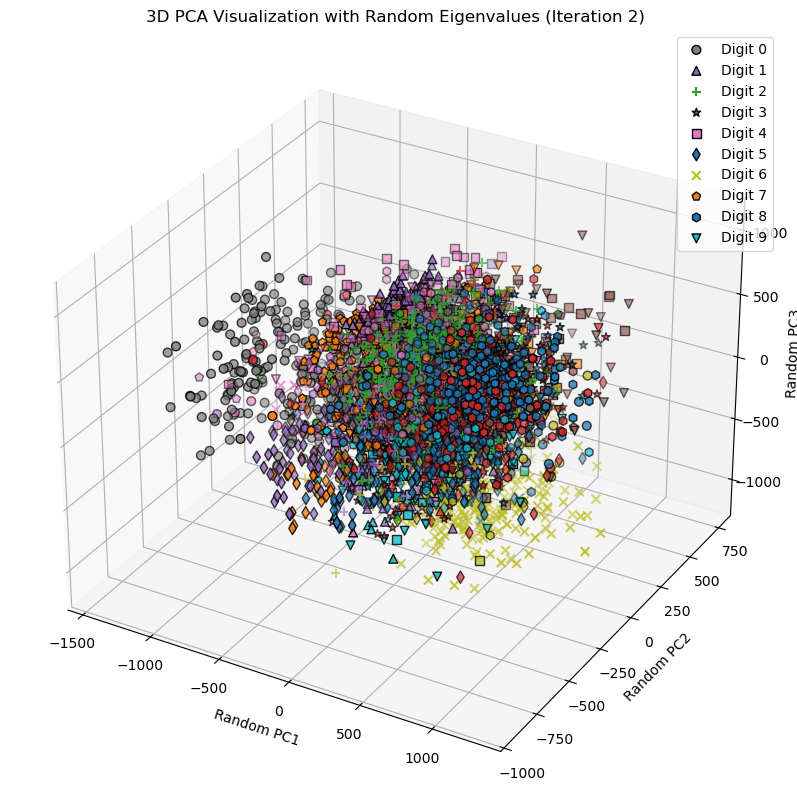

/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


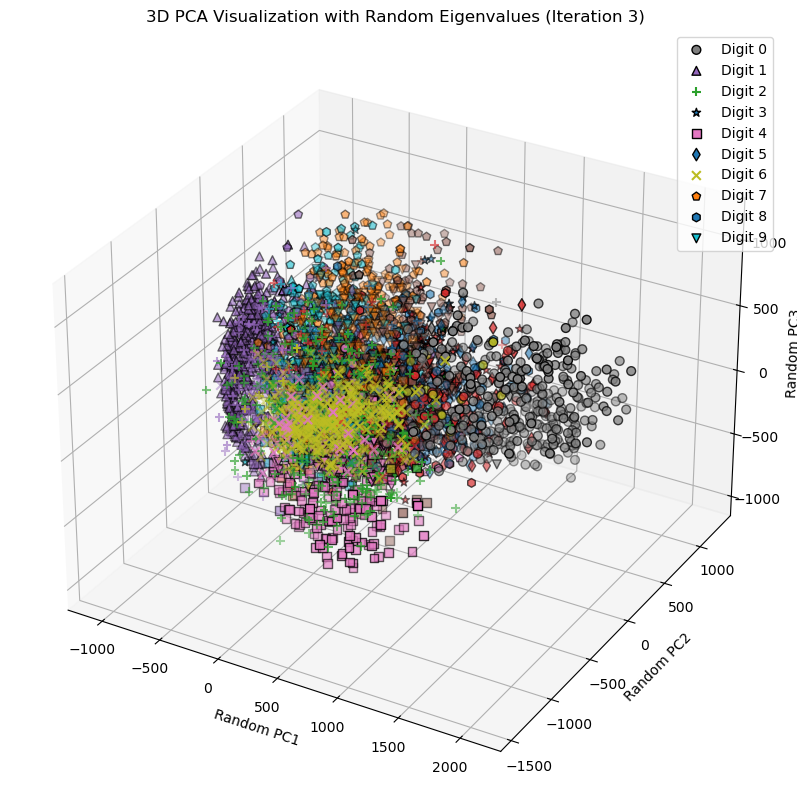

/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


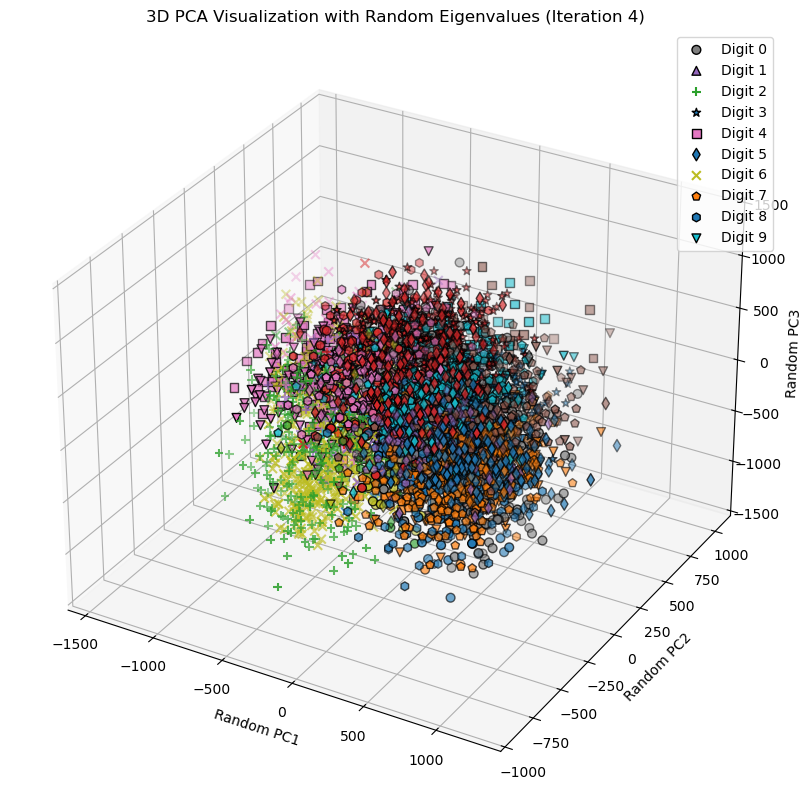

/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4407/2012146389.py:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


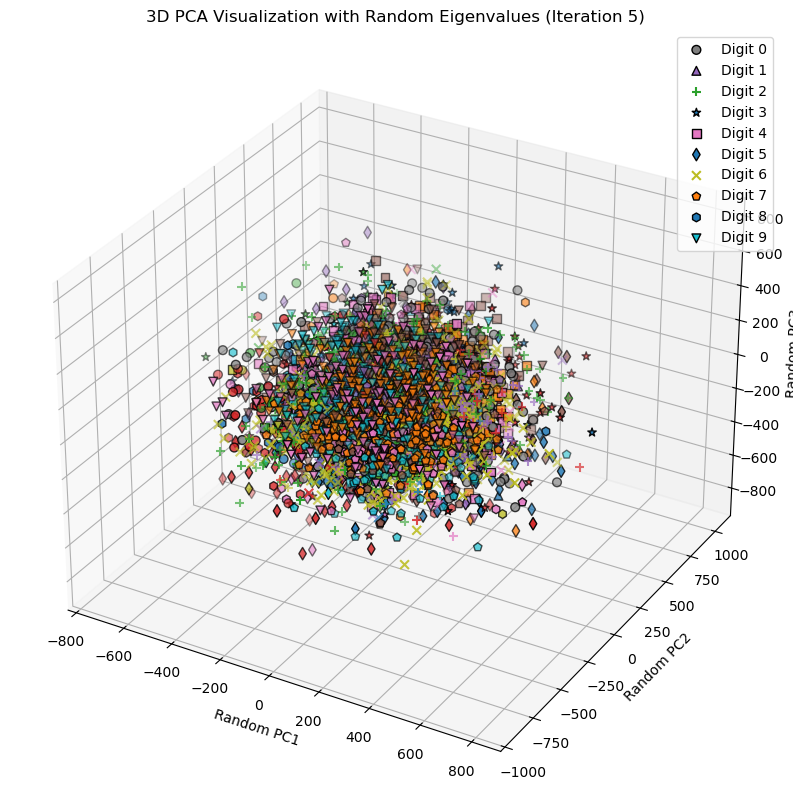

In [21]:
### D)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ensure X_mnist is a NumPy array
X_mnist = np.array(X_mnist)

# Run several iterations with random eigenvalue selections
for i in range(5):  # You can adjust the number of iterations
    # Randomly select 3 eigenvalues from the top 20
    random_indices = np.random.choice(20, 3, replace=False)
    
    # Perform PCA with the selected eigenvalues
    pca_random = PCA(n_components=20)
    X_pca_20 = pca_random.fit_transform(X_mnist)
    X_random_pca = X_pca_20[:, random_indices]
    
    # Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot each digit with its corresponding shape and cluster color
    for digit in np.unique(y_mnist):
        mask = (y_mnist == digit)
        ax.scatter(
            X_random_pca[mask][:, 0],  # First random component
            X_random_pca[mask][:, 1],  # Second random component
            X_random_pca[mask][:, 2],  # Third random component
            c=[colors[label] for label in kmeans_labels[mask]],  # Cluster color
            marker=markers[digit],  # Shape for true label
            label=f'Digit {digit}',
            s=40,
            edgecolors='k'
        )
    
    ax.set_title(f'3D PCA Visualization with Random Eigenvalues (Iteration {i + 1})')
    ax.set_xlabel('Random PC1')
    ax.set_ylabel('Random PC2')
    ax.set_zlabel('Random PC3')
    ax.legend(loc='best')
    plt.show()

### Problem 5

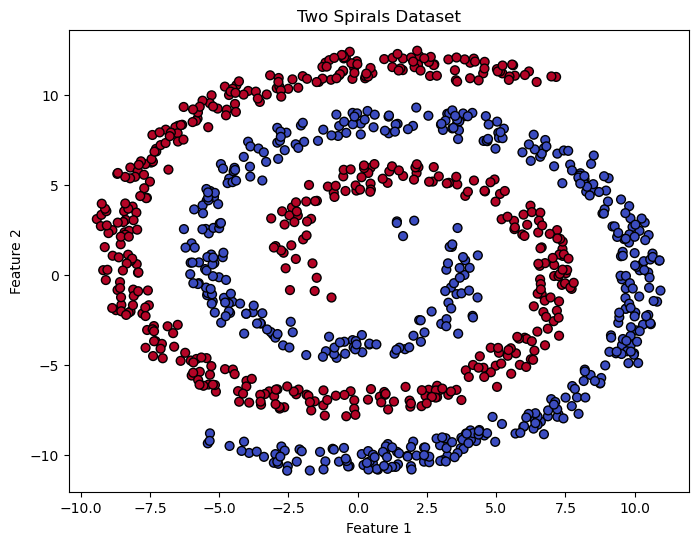

Two Spirals Dataset:
Accuracy: 0.6633
RMSE: 1.1605
----------------------------------------


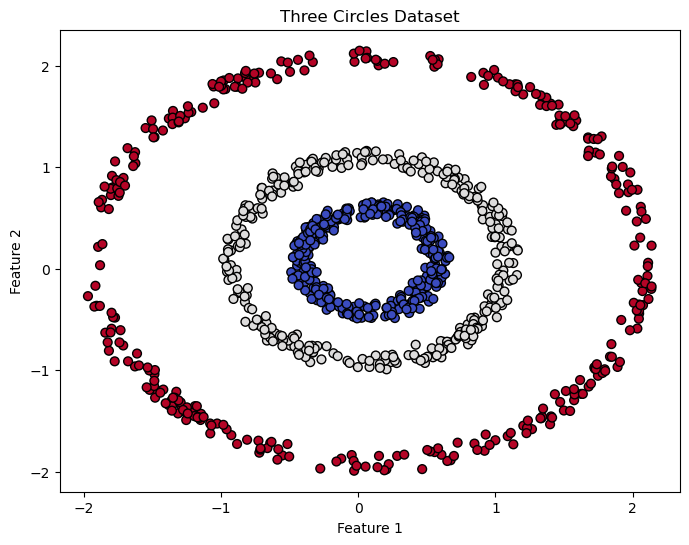

Three Circles Dataset:
Accuracy: 0.2400
RMSE: 1.2490
----------------------------------------


In [24]:
### A)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Load dataset from text file with delimiter
def load_dataset(filename, delimiter):
    data = np.loadtxt(filename, delimiter=delimiter)
    X = data[:, :2]  # First two columns: Features
    y = data[:, 2]   # Third column: Labels
    return X, y

# Plot dataset
def plot_dataset(X, y, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Train and evaluate logistic regression
def train_logistic_regression(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{dataset_name} Dataset:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("-" * 40)

# Load and process Two Spirals dataset (Tab-separated)
X_spirals, y_spirals = load_dataset("twospirals.txt", delimiter="\t")
plot_dataset(X_spirals, y_spirals, "Two Spirals Dataset")
train_logistic_regression(X_spirals, y_spirals, "Two Spirals")

# Load and process Three Circles dataset (Comma-separated)
X_circles, y_circles = load_dataset("threecircles.txt", delimiter=",")
plot_dataset(X_circles, y_circles, "Three Circles Dataset")
train_logistic_regression(X_circles, y_circles, "Three Circles")

In [ ]:
### B)

In [28]:
def rbf_kernel(DIST_euclid, sigma=3):
    K = np.exp(-DIST_euclid / (2 * sigma ** 2))
    return K

In [30]:
def normalize_kernel(K):
    N = K.shape[0]
    U = np.ones((N, N)) / N  # NxN matrix of all ones scaled by N
    Kn = K - np.dot(U, K) - np.dot(K, U) + np.dot(np.dot(U, K), U)
    return Kn

In [32]:
def compute_kernel_eigen(Kn):
    # Compute eigenvalues and eigenvectors of the normalized kernel matrix
    eigenvalues, eigenvectors = np.linalg.eig(Kn)
    # Sort eigenvalues in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues_sorted = eigenvalues[sorted_indices]
    eigenvectors_sorted = eigenvectors[:, sorted_indices]
    return eigenvalues_sorted, eigenvectors_sorted

In [34]:
def project_data(Kn, eigenvectors_sorted, num_components):
    X_proj = np.dot(Kn, eigenvectors_sorted[:, :num_components])
    return X_proj

In [38]:
# Run KernelPCA with 3 principal components
X_kernel_pca = kernel_pca(X_spirals, sigma=3, num_components=3)

print(X_kernel_pca.shape)  

(1000, 3)


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split

def load_dataset(filename, delimiter):
    data = np.loadtxt(filename, delimiter=delimiter)
    X = data[:, :2]  # First two columns: Features
    y = data[:, 2]   # Third column: Labels
    return X, y

# Plot dataset
def plot_dataset(X, y, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Compute the pairwise squared Euclidean distance
def compute_squared_distance(X):
    X2 = np.sum(X**2, axis=1)[:, np.newaxis]  # Column vector of squared norms
    DIST = X2 + X2.T - 2 * np.dot(X, X.T)  # Pairwise squared Euclidean distance
    return DIST

# Gaussian Kernel function
def gaussian_kernel(DIST, sigma=3.0):
    return np.exp(-DIST / (2 * sigma ** 2))

# Normalize the kernel matrix
def normalize_kernel(K):
    N = K.shape[0]
    U = np.ones((N, N)) / N
    K_normalized = K - np.dot(U, K) - np.dot(K, U) + np.dot(np.dot(U, K), U)
    return K_normalized
# Kernel PCA: Compute the eigenvectors and project the data
def kernel_pca(X, sigma=3.0, n_components=3):
    DIST = compute_squared_distance(X)
    
    # Compute the kernel matrix
    K = gaussian_kernel(DIST, sigma)
    
    # Normalize the kernel matrix
    K_normalized = normalize_kernel(K)
    
    # Eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(K_normalized)
    
    # Sort the eigenvalues in descending order
    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]
    
    # Select the top n_components eigenvectors
    X_transformed = np.dot(K_normalized, eigenvectors[:, :n_components])
    return X_transformed

# Train and evaluate logistic regression
def train_logistic_regression(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{dataset_name} Dataset:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("-" * 40)

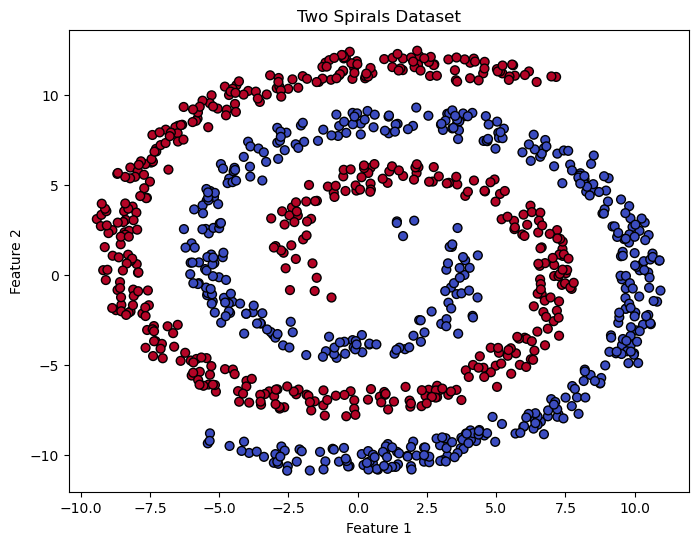

Two Spirals KernelPCA Dataset:
Accuracy: 0.6567
RMSE: 1.1719
----------------------------------------


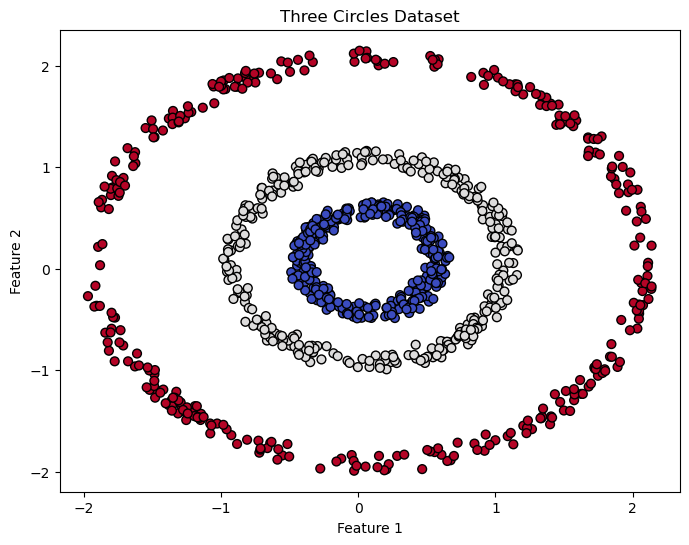

Three Circles KernelPCA Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split

def load_dataset(filename, delimiter):
    data = np.loadtxt(filename, delimiter=delimiter)
    X = data[:, :2]  # First two columns: Features
    y = data[:, 2]   # Third column: Labels
    return X, y

# Plot dataset
def plot_dataset(X, y, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Compute the pairwise squared Euclidean distance
def compute_squared_distance(X):
    X2 = np.sum(X**2, axis=1)[:, np.newaxis]  # Column vector of squared norms
    DIST = X2 + X2.T - 2 * np.dot(X, X.T)  # Pairwise squared Euclidean distance
    return DIST

# Gaussian Kernel function
def gaussian_kernel(DIST, sigma=3.0):
    return np.exp(-DIST / (2 * sigma ** 2))

# Normalize the kernel matrix
def normalize_kernel(K):
    N = K.shape[0]
    U = np.ones((N, N)) / N
    K_normalized = K - np.dot(U, K) - np.dot(K, U) + np.dot(np.dot(U, K), U)
    return K_normalized

# Kernel PCA: Compute the eigenvectors and project the data
def kernel_pca(X, sigma=3.0, n_components=3):
    DIST = compute_squared_distance(X)
    
    # Compute the kernel matrix
    K = gaussian_kernel(DIST, sigma)
    
    # Normalize the kernel matrix
    K_normalized = normalize_kernel(K)
    
    # Eigenvalue decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(K_normalized)
    
    # Sort the eigenvalues in descending order
    sorted_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_idx]
    eigenvectors = eigenvectors[:, sorted_idx]
    
    # Select the top n_components eigenvectors
    X_transformed = np.dot(K_normalized, eigenvectors[:, :n_components])
    return X_transformed

# Train and evaluate logistic regression
def train_logistic_regression(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{dataset_name} Dataset:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("-" * 40)

# Load and process Two Spirals dataset 
X_spirals, y_spirals = load_dataset("twospirals.txt", delimiter="\t")
plot_dataset(X_spirals, y_spirals, "Two Spirals Dataset")

# Apply KernelPCA on Two Spirals dataset
X_spirals_kernel_pca = kernel_pca(X_spirals, sigma=3.0, n_components=3)
train_logistic_regression(X_spirals_kernel_pca, y_spirals, "Two Spirals KernelPCA")

# Load and process Three Circles dataset 
X_circles, y_circles = load_dataset("threecircles.txt", delimiter=",")
plot_dataset(X_circles, y_circles, "Three Circles Dataset")

# Apply KernelPCA on Three Circles dataset
X_circles_kernel_pca = kernel_pca(X_circles, sigma=3.0, n_components=3)
train_logistic_regression(X_circles_kernel_pca, y_circles, "Three Circles KernelPCA")

The performance degrades for the spiral dataset as it has multiple complex twists, which the radial kernel is not able to capture properly; thus, we see a slight lower accuracy, but in the case of circle data, we see a 100% accuracy.

In [20]:
### C)

In [29]:
# Load and process Two Spirals dataset 
X_spirals, y_spirals = load_dataset("twospirals.txt", delimiter="\t")
X_circles, y_circles = load_dataset("threecircles.txt", delimiter=",")

In [35]:
# Train and evaluate logistic regression
def train_logistic_regression(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{dataset_name} Dataset:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("-" * 40)
    
    # Return accuracy and RMSE
    return accuracy, rmse

In [39]:
T_values = [3, 10, 20, 30, 50, 100]
results = []
for T in T_values:
    X_kernel_pca = kernel_pca(X_spirals, sigma=3.0, n_components=T)
    accuracy, rmse = train_logistic_regression(X_kernel_pca, y_spirals, T)
    results.append((T, accuracy, rmse))
    print(f"T = {T}: Accuracy = {accuracy:.4f}, RMSE = {rmse:.4f}")

3 Dataset:
Accuracy: 0.6567
RMSE: 1.1719
----------------------------------------
T = 3: Accuracy = 0.6567, RMSE = 1.1719
10 Dataset:
Accuracy: 0.5767
RMSE: 1.3013
----------------------------------------
T = 10: Accuracy = 0.5767, RMSE = 1.3013
20 Dataset:
Accuracy: 0.8767
RMSE: 0.7024
----------------------------------------
T = 20: Accuracy = 0.8767, RMSE = 0.7024
30 Dataset:
Accuracy: 0.9800
RMSE: 0.2828
----------------------------------------
T = 30: Accuracy = 0.9800, RMSE = 0.2828
50 Dataset:
Accuracy: 0.9833
RMSE: 0.2582
----------------------------------------
T = 50: Accuracy = 0.9833, RMSE = 0.2582
100 Dataset:
Accuracy: 0.9833
RMSE: 0.2582
----------------------------------------
T = 100: Accuracy = 0.9833, RMSE = 0.2582


From the above results, we can see that from the T value of 20 to 30 there is a huge improvement in the accuracy for the spirals dataset, but when we move past from 30 to 50 there is a very small improvement in accuracy, suggesting that the value of T to get good results should be somewhere around 30.

In [42]:
T_values = [3, 10, 20, 30, 50, 100]
results = []
for T in T_values:
    X_kernel_pca = kernel_pca(X_circles, sigma=3.0, n_components=T)
    accuracy, rmse = train_logistic_regression(X_kernel_pca, y_circles, T)
    results.append((T, accuracy, rmse))
    print(f"T = {T}: Accuracy = {accuracy:.4f}, RMSE = {rmse:.4f}")

3 Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------
T = 3: Accuracy = 1.0000, RMSE = 0.0000
10 Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------
T = 10: Accuracy = 1.0000, RMSE = 0.0000
20 Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------
T = 20: Accuracy = 1.0000, RMSE = 0.0000
30 Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------
T = 30: Accuracy = 1.0000, RMSE = 0.0000
50 Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------
T = 50: Accuracy = 1.0000, RMSE = 0.0000
100 Dataset:
Accuracy: 1.0000
RMSE: 0.0000
----------------------------------------
T = 100: Accuracy = 1.0000, RMSE = 0.0000


We get 100% accuracy for every iteration; this suggests that the kernel function is perfectly seperating the classes for the circles dataset even with a smaller number of components T. Or this might also suggest overfitting in some cases.